# **Data Loading**

In [1]:
# Import the required modules
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("creditcard.csv")

# Show the dataset
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# **Data Exploration**

In [2]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (284807, 31)
Missing values: 0
Duplicate rows: 1081


In [3]:
df = df.drop_duplicates().reset_index(drop=True)
print("After dedup:", df.shape)

After dedup: (283726, 31)


# **Class Balance Check**

In [4]:
counts = df["Class"].value_counts()
fraud_rate = df["Class"].mean()

print(counts)
print(f"\nFraud rate: {fraud_rate*100:.4f}%")
print(f"That's 1 fraud in every {1/fraud_rate:.0f} transactions")
print(f"Imbalance ratio: {counts[0]/counts[1]:.0f} : 1")

Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate: 0.1667%
That's 1 fraud in every 600 transactions
Imbalance ratio: 599 : 1


# **Visualizing**

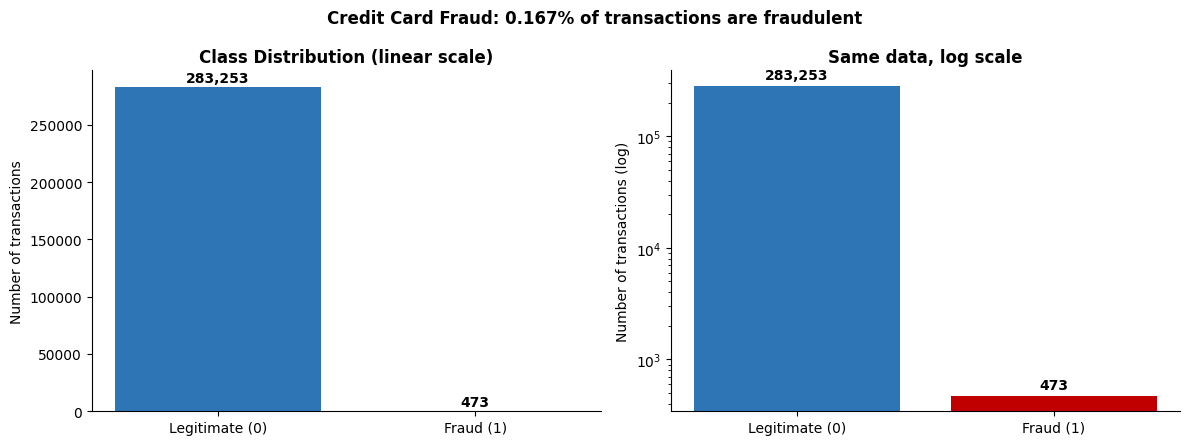

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

bars = ax[0].bar(["Legitimate (0)", "Fraud (1)"], counts.values, color=["#2E75B6", "#C00000"])
ax[0].set_title("Class Distribution (linear scale)", fontweight="bold")
ax[0].set_ylabel("Number of transactions")
for r, v in zip(bars, counts.values):
    ax[0].text(r.get_x() + r.get_width()/2, v + 4000, f"{v:,}", ha="center", fontweight="bold")

bars = ax[1].bar(["Legitimate (0)", "Fraud (1)"], counts.values, color=["#2E75B6", "#C00000"])
ax[1].set_yscale("log")
ax[1].set_title("Same data, log scale", fontweight="bold")
ax[1].set_ylabel("Number of transactions (log)")
for r, v in zip(bars, counts.values):
    ax[1].text(r.get_x() + r.get_width()/2, v*1.15, f"{v:,}", ha="center", fontweight="bold")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Credit Card Fraud: {fraud_rate*100:.3f}% of transactions are fraudulent",
             fontweight="bold")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=140)
plt.show()

# **Split And Scale**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, frauds: {y_train.sum()}")
print(f"Test:  {X_test.shape}, frauds: {y_test.sum()}")

Train: (226980, 30), frauds: 378
Test:  (56746, 30), frauds: 95


# **Train Baseline And Balanced Models**

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, average_precision_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def evaluate(name, model, X_fit=None, y_fit=None):
    model.fit(X_train_s if X_fit is None else X_fit,
              y_train    if y_fit is None else y_fit)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "model": name,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":    recall_score(y_test, pred),
        "f1":        f1_score(y_test, pred),
        "PR_AUC":    average_precision_score(y_test, proba),
        "TP": tp, "FP": fp, "FN": fn,
    }

results = []

# The "do nothing" model — never predicts fraud
results.append(evaluate("AllZeros (never fraud)",
                        DummyClassifier(strategy="constant", constant=0)))

# Baseline
results.append(evaluate("Baseline LogReg",
                        LogisticRegression(max_iter=1000, random_state=42)))

# Technique 1: class weighting
results.append(evaluate("class_weight='balanced'",
                        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)))

# Technique 2: SMOTE — resample TRAIN ONLY
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train_s, y_train)
print(f"SMOTE train set: {X_sm.shape}, frauds now {int(y_sm.sum()):,}")
results.append(evaluate("SMOTE", LogisticRegression(max_iter=1000, random_state=42), X_sm, y_sm))

# Technique 3: undersampling
X_us, y_us = RandomUnderSampler(random_state=42).fit_resample(X_train_s, y_train)
print(f"Undersampled train set: {X_us.shape}")
results.append(evaluate("Undersampling", LogisticRegression(max_iter=1000, random_state=42), X_us, y_us))

comparison = pd.DataFrame(results)
print(comparison[["model", "accuracy", "precision", "recall", "f1", "PR_AUC"]].round(4).to_string(index=False))

SMOTE train set: (453204, 30), frauds now 226,602
Undersampled train set: (756, 30)
                  model  accuracy  precision  recall     f1  PR_AUC
 AllZeros (never fraud)    0.9983     0.0000  0.0000 0.0000  0.0017
        Baseline LogReg    0.9991     0.8462  0.5789 0.6875  0.6920
class_weight='balanced'    0.9753     0.0564  0.8737 0.1059  0.6719
                  SMOTE    0.9737     0.0530  0.8737 0.1000  0.6750
          Undersampling    0.9722     0.0504  0.8737 0.0953  0.5896


# **Confirmation**

In [8]:
from sklearn.metrics import precision_recall_curve

bal = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
bal.fit(X_train_s, y_train)
proba = bal.predict_proba(X_test_s)[:, 1]

for th in [0.5, 0.9, 0.99, 0.999]:
    pred = (proba >= th).astype(int)
    print(f"threshold={th:<6} precision={precision_score(y_test, pred):.4f} "
          f"recall={recall_score(y_test, pred):.4f} f1={f1_score(y_test, pred):.4f}")

threshold=0.5    precision=0.0564 recall=0.8737 f1=0.1059
threshold=0.9    precision=0.2625 recall=0.8316 f1=0.3990
threshold=0.99   precision=0.6579 recall=0.7895 f1=0.7177
threshold=0.999  precision=0.7449 recall=0.7684 f1=0.7565


# **Comparison Plot**

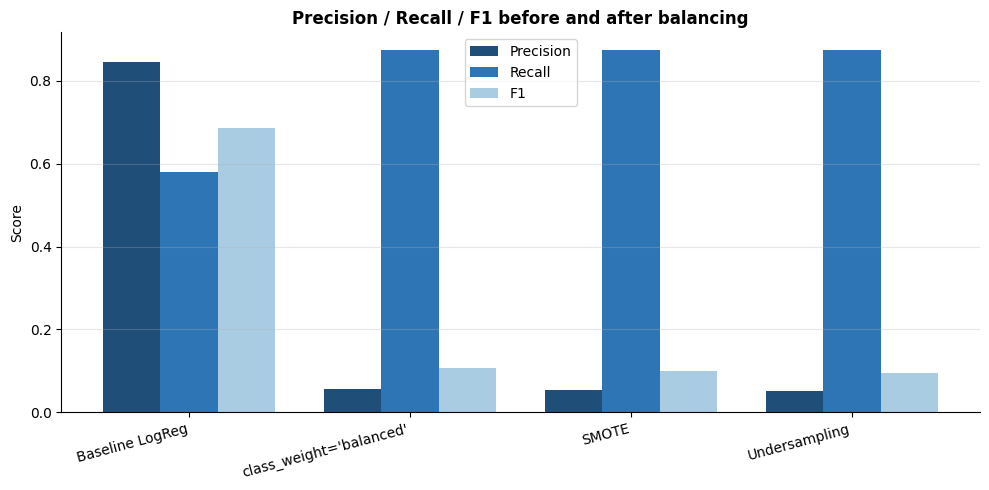

In [9]:
plot_df = comparison[comparison["model"] != "AllZeros (never fraud)"]
x = np.arange(len(plot_df)); w = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, plot_df["precision"], w, label="Precision", color="#1F4E79")
ax.bar(x,     plot_df["recall"],    w, label="Recall",    color="#2E75B6")
ax.bar(x + w, plot_df["f1"],        w, label="F1",        color="#A9CCE3")
ax.set_xticks(x); ax.set_xticklabels(plot_df["model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 before and after balancing", fontweight="bold")
ax.legend(); ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=140)
plt.show()

### **Why "accuracy" would have been a misleading metric**

Only 0.167% of transactions in this dataset are fraudulent — 473 out of 283,726. A model that
simply predicts "not fraud" for every single transaction achieves **99.83% accuracy** while
catching **zero** frauds. I verified this directly with a `DummyClassifier`: accuracy 0.9983,
recall 0.000, F1 0.000. By the accuracy metric it looks near-perfect; in reality it is
completely worthless, because the entire purpose of the model is to find the 0.167% it ignores.

The problem is that accuracy weights every transaction equally, so a metric dominated by the
majority class simply measures how big the majority is. Worse, it moves in the wrong direction
here: my baseline model scored **99.91% accuracy** while the balanced model scored **97.53%** —
yet the balanced model caught 83 frauds to the baseline's 55. Optimising for accuracy would
have led me to choose the model that misses more fraud.

The right metrics are those that focus on the minority class: **recall** (what fraction of real
frauds did we catch?), **precision** (of the transactions we flagged, how many were actually
fraud?), **F1** (their harmonic mean), and **PR-AUC**, which summarises the
precision-recall trade-off across all thresholds without depending on any single cutoff. For a
fraud system the choice between them is a business decision — the cost of a missed fraud versus
the cost of an analyst investigating a false alarm — and accuracy answers neither question.